In [1]:
import torch
import torch.nn as nn  # Neural network module
import matplotlib.pyplot as plt  # For plotting

In [2]:
#  Generate Input Data (X) and Output Data (y)
torch.manual_seed(71)  # For reproducibility
#Include your code here
X = torch.linspace(1, 100, 100).reshape(-1, 1)
noise = torch.randn(X.size()) * 10
y = 2 * X + 1 + noise


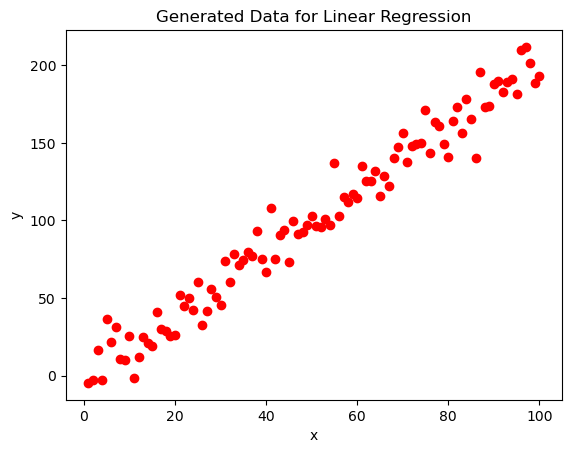

In [3]:
# Plot the original data
plt.scatter(X, y, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data for Linear Regression')
plt.show()

In [4]:
# Define the Linear Model Class
class Model(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)  # Linear layer

    def forward(self, x):
        return self.linear(x)


In [5]:
# Initialize the Model
torch.manual_seed(59)  # Ensure same initial weights
model = Model(1, 1)

In [6]:
# Print Initial Weights and Bias
initial_weight = model.linear.weight.item()
initial_bias = model.linear.bias.item()
print("\nName: Jeevan E S")
print("Register No: 212223230091")
print(f'Initial Weight: {initial_weight:.8f}, Initial Bias: {initial_bias:.8f}\n')


Name: Jeevan E S
Register No: 212223230091
Initial Weight: 0.10597813, Initial Bias: 0.96379614



In [7]:
# Define Loss Function & Optimizer
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

In [8]:
# Train the Model
epochs = 100
losses = []

for epoch in range(1, epochs + 1):
    y_pred = model(X)
    loss = loss_function(y_pred, y)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print details
    print(f'epoch: {epoch:2}  loss: {loss.item():10.8f}  '
          f'weight: {model.linear.weight.item():10.8f}  '
          f'bias: {model.linear.bias.item():10.8f}')

epoch:  1  loss: 12172.70605469  weight: 1.38313794  bias: 0.98272932
epoch:  2  loss: 1379.14550781  weight: 1.79585242  bias: 0.98875940
epoch:  3  loss: 252.02304077  weight: 1.92922211  bias: 0.99061984
epoch:  4  loss: 134.32263184  weight: 1.97232175  bias: 0.99113286
epoch:  5  loss: 122.03151703  weight: 1.98625076  bias: 0.99121046
epoch:  6  loss: 120.74784851  weight: 1.99075317  bias: 0.99114740
epoch:  7  loss: 120.61366272  weight: 1.99220943  bias: 0.99103886
epoch:  8  loss: 120.59950256  weight: 1.99268138  bias: 0.99091566
epoch:  9  loss: 120.59786224  weight: 1.99283516  bias: 0.99078768
epoch: 10  loss: 120.59754181  weight: 1.99288619  bias: 0.99065816
epoch: 11  loss: 120.59734344  weight: 1.99290395  bias: 0.99052817
epoch: 12  loss: 120.59719849  weight: 1.99291110  bias: 0.99039805
epoch: 13  loss: 120.59701538  weight: 1.99291468  bias: 0.99026787
epoch: 14  loss: 120.59685516  weight: 1.99291718  bias: 0.99013770
epoch: 15  loss: 120.59667969  weight: 1.9929

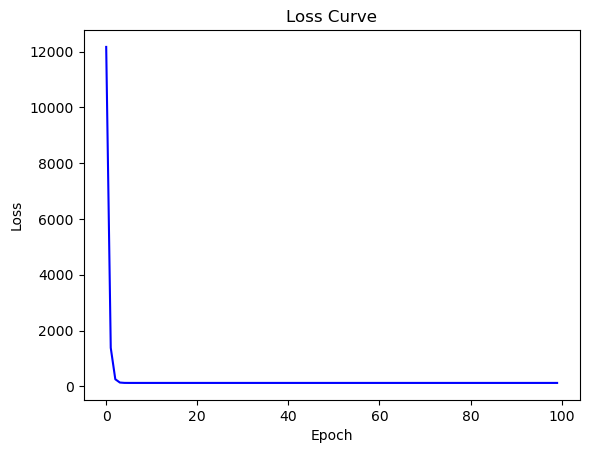

In [9]:
# Plot Loss Curve
plt.plot(range(epochs), losses, color='blue')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Loss Curve')
plt.show()

In [10]:
# Final Weights & Bias
final_weight = model.linear.weight.item()
final_bias = model.linear.bias.item()
print("\nName: Jeevan E S ")
print("Register No: 212223230091")
print(f'\nFinal Weight: {final_weight:.8f}, Final Bias: {final_bias:.8f}')


Name: Jeevan E S 
Register No: 212223230091

Final Weight: 1.99308419, Final Bias: 0.97896451


In [11]:
#  Best-Fit Line Calculation
x1 = torch.tensor([X.min().item(), X.max().item()]) # Find min and max values of X
y1 = x1 * final_weight + final_bias # Compute corresponding y-values using trained model

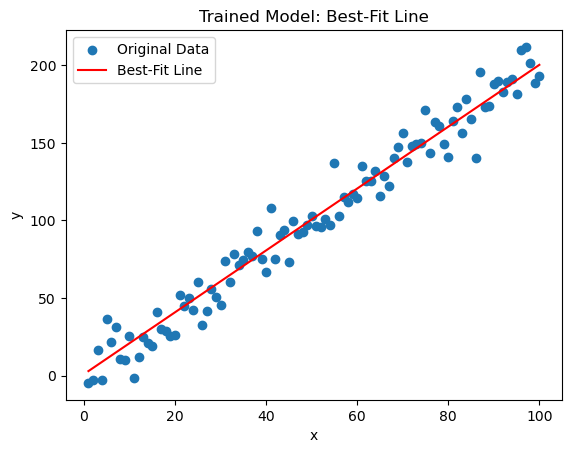

In [12]:
# Plot Original Data & Best-Fit Line
plt.scatter(X, y, label="Original Data")
plt.plot(x1, y1, 'r', label="Best-Fit Line")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trained Model: Best-Fit Line')
plt.legend()
plt.show()

In [13]:
# Prediction for x = 120
x_new = torch.tensor([[120.0]])  # New input as a tensor
y_new_pred = model(x_new).item()  # Predict using trained model
print("\nName: Jeevan E S ")
print("Register No: 212223230091")
print(f"\nPrediction for x = 120: {y_new_pred:.8f}")


Name: Jeevan E S 
Register No: 212223230091

Prediction for x = 120: 240.14906311
